In [1]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
import numpy as np

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6452.04it/s]


Ready!


In [2]:
import torch.nn.functional as F

text = "The cat sat on the mat and looked around"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits[0]  # [n_tokens, 50257]


losses = []
for i in range(len(tokens) - 1):
    actual_id = inputs['input_ids'][0][i+1]
    loss = F.cross_entropy(
        logits[i].unsqueeze(0), 
        actual_id.unsqueeze(0)
    ).item()
    losses.append(loss)

print(f"{'Token':<12} {'Next Token':<12} {'Loss':<8}")
print("-"*35)
for i, loss in enumerate(losses):
    print(f"{tokens[i]:<12} {tokens[i+1]:<12} {loss:.4f}")

print(f"\nAverage Loss: {np.mean(losses):.4f}")

Token        Next Token   Loss    
-----------------------------------
The          Ġcat         9.1956
Ġcat         Ġsat         7.2592
Ġsat         Ġon          1.4962
Ġon          Ġthe         0.7903
Ġthe         Ġmat         5.5105
Ġmat         Ġand         1.8979
Ġand         Ġlooked      2.9265
Ġlooked      Ġaround      2.8633

Average Loss: 3.9925


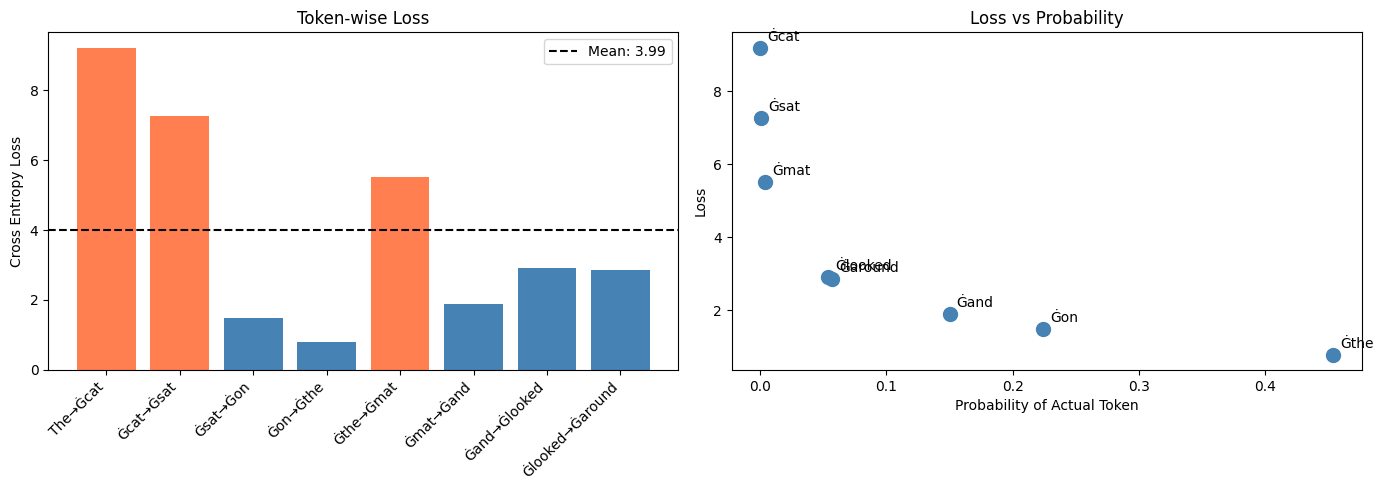

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss bar chart
token_pairs = [f"{tokens[i]}→{tokens[i+1]}" 
               for i in range(len(losses))]

colors = ["coral" if l > 3 else "steelblue" for l in losses]
axes[0].bar(range(len(losses)), losses, color=colors)
axes[0].set_xticks(range(len(losses)))
axes[0].set_xticklabels(token_pairs, rotation=45, ha="right")
axes[0].axhline(y=np.mean(losses), color="black", 
                linestyle="--", label=f"Mean: {np.mean(losses):.2f}")
axes[0].set_ylabel("Cross Entropy Loss")
axes[0].set_title("Token-wise Loss")
axes[0].legend()

# Loss vs Probability scatter
probs_list = [torch.softmax(logits[i], dim=0)
              [inputs['input_ids'][0][i+1]].item() 
              for i in range(len(losses))]

axes[1].scatter(probs_list, losses, color="steelblue", s=100)
for i, (p, l) in enumerate(zip(probs_list, losses)):
    axes[1].annotate(tokens[i+1], (p, l), 
                     textcoords="offset points", xytext=(5,5))
axes[1].set_xlabel("Probability of Actual Token")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss vs Probability")

plt.tight_layout()
plt.show()

* **Cross Entropy Loss** (Cross Entropy Loss) measures **how wrong the model’s predictions are**.

* **High loss** → the model’s prediction was **incorrect or uncertain**.

* **Low loss** → the model was **confident and likely correct**.

* Loss and probability are **inversely related** — as probability increases, loss decreases.

* At the **start of a sentence**, loss is usually **higher** because there is **less context available** for the model to make accurate predictions.
